In [ ]:
!pip install import_ipynb
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/МИФИ Машинное обучение/Классическое машинное обучение/')

import import_ipynb
import regression_pipeline as pipelines

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
result = pipelines.run_regression_task(pipelines.RegressionTask(name="SI", target_column="log_SI"), True)

'start task SI'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'fit model :Ridge'

{'task': 'SI',
 'model': 'Ridge',
 'cv_r2_mean': 0.0803497166162304,
 'test_mae': 0.6054935037042781,
 'test_rmse': np.float64(0.7856604196422073),
 'test_r2': 0.1039378884462383,
 'best_params': '{"model__alpha": 100.0, "selector__k": 50}'}

'fit model :Lasso'

...

{'task': 'SI',
 'model': 'RandomForest',
 'cv_r2_mean': 0.26734569785491236,
 'test_mae': 0.5471199865856718,
 'test_rmse': np.float64(0.7398025233102459),
 'test_r2': 0.20548887698565532,
 'best_params': '{"selector__k": 50, "model__n_estimators": 400, "model__min_samples_split": 2, "model__min_samples_leaf": 1, "model__max_features": 0.8, "model__max_depth": 10}'}

'fit model :GradientBoosting'

{'task': 'SI',
 'model': 'GradientBoosting',
 'cv_r2_mean': 0.2453464204040973,
 'test_mae': 0.5572841846849086,
 'test_rmse': np.float64(0.7364413736565083),
 'test_r2': 0.21269189216428597,
 'best_params': '{"selector__k": 50, "model__subsample": 0.7, "model__n_estimators": 200, "model__min_samples_split": 2, "model__min_samples_leaf": 2, "model__max_depth": 3, "model__learning_rate": 0.02}'}

'fit model :XGBoost'

{'task': 'SI',
 'model': 'XGBoost',
 'cv_r2_mean': 0.2627458454162034,
 'test_mae': 0.5375157463874037,
 'test_rmse': np.float64(0.7295985596152371),
 'test_r2': 0.22725482689699128,
 'best_params': '{"selector__k": 50, "model__subsample": 0.85, "model__n_estimators": 300, "model__max_depth": 7, "model__learning_rate": 0.01}'}

Прогнозирование индекса селективности является наиболее сложным этапом исследования, так как данный параметр является вычисляемым $SI=CC50​/IC50​$ и аккумулирует в себе погрешности измерения и моделирования сразу двух  показателей. Для исследования использовался тот же пайплайн что и для CC50​,IC50, были рассмотренны различные модели и совершен автоматический подбор гиперпараметров.​

Выводы:

1. Наилучшую предсказательную способность продемонстрировали XGBoost ($R^2$=0.227) и RandomForest ($R^2$=0.206). Несмотря на низкие абсолютные значения метрик, модели показывают стабильность, тк разрыв между кросс-валидацией и тестом минимален.

2. Линейные модели (Lasso, Ridge) показали отрицательный коэффициент детерминации. Это подтверждает в третий раз гипотезу о сложности биохимических взаимодействи и о том, что взаимосвязь между химической структурой и селективностью действия носит комплексный, нелинейный характер.

3. Выбор моделями различных стратегий отбора (k=50 для XGBoost и k=25 для RF) указывает на то что сигнал в данных сильно зашумлен и лишь небольшая часть дескрипторов реально влияет на избирательность действия.

| Модель | $R^2$ (Test) | CV $R^2$ (mean) | MAE | RMSE | Лучшие параметры |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **XGBoost** | **0.2273** | 0.2627 | 0.5375 | 0.7296 | k: 50, n_est: 300, depth: 7, lr: 0.01, sub: 0.85 |
| **RandomForest** | **0.2057** | 0.2673 | 0.5471 | 0.7399 | k: 25, n_est: 200, depth: 20, split: 2, leaf: 1 |
| **GradientBoosting** | **0.2127** | 0.2453 | 0.5573 | 0.7364 | k: 50, n_est: 200, depth: 3, lr: 0.02, sub: 0.7 |
| **Lasso** | **-0.0881** | 0.1542 | 0.6385 | 0.8654 | k: 50, alpha: 0.001 |
| **ElasticNet** | **-0.0924** | 0.1539 | 0.6410 | 0.8672 | k: 50, alpha: 0.001, l1_ratio: 0.2 |
| **Ridge** | **-0.1245** | 0.1545 | 0.6520 | 0.8812 | k: 50, alpha: 1.0 |

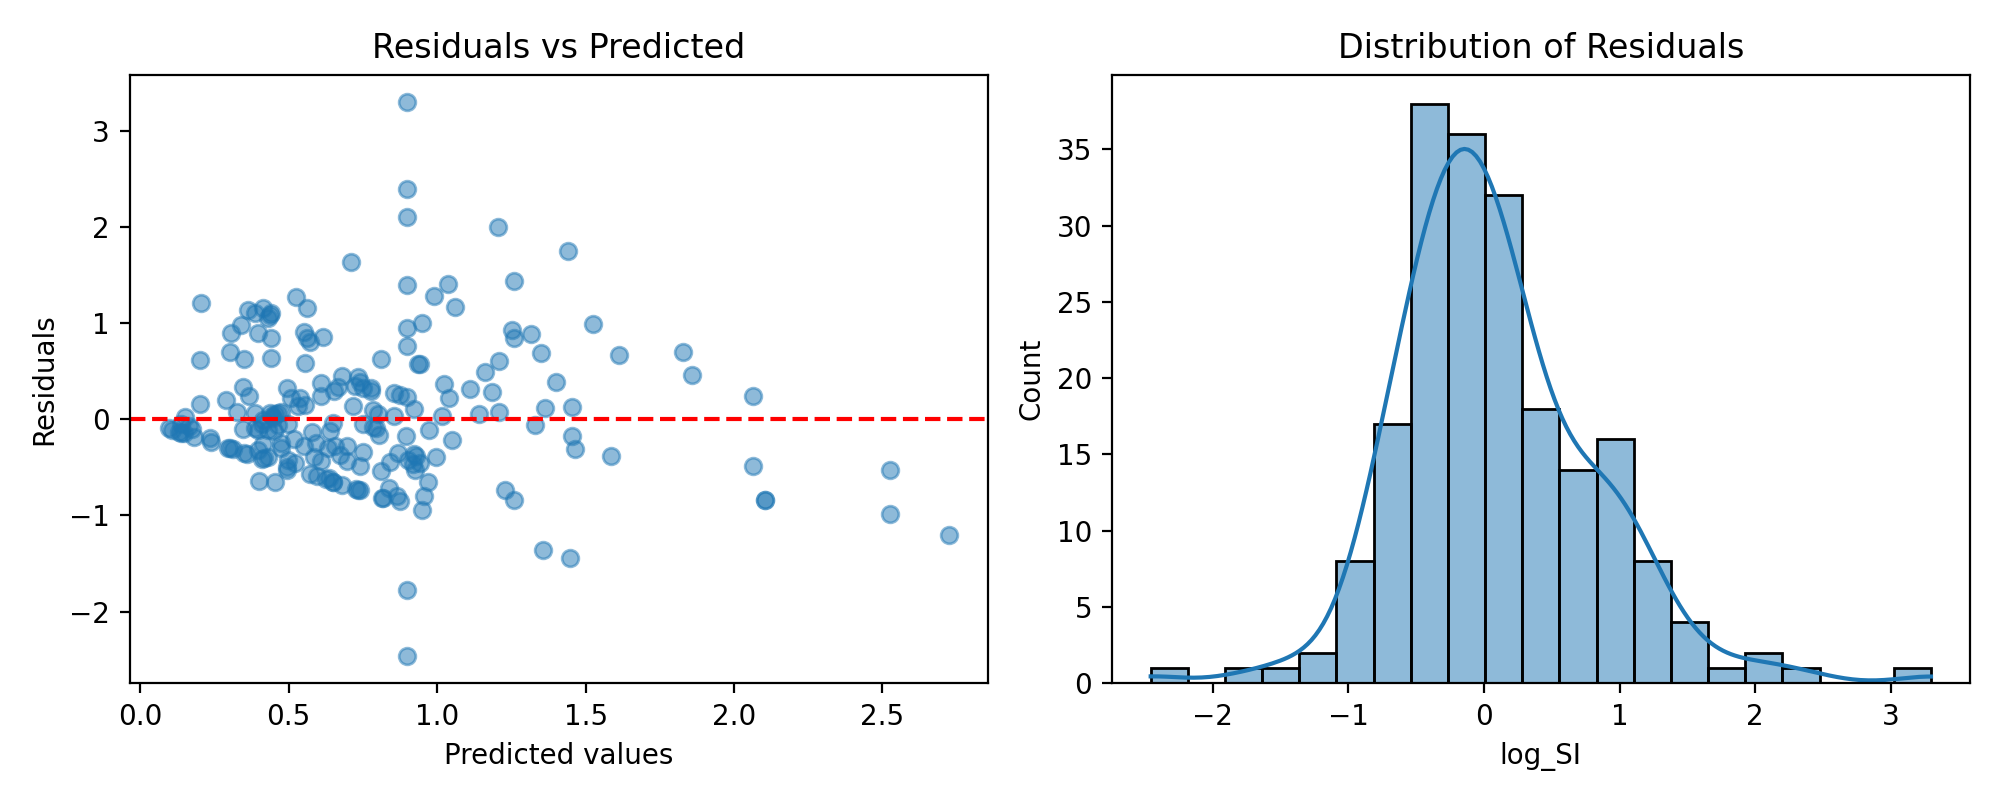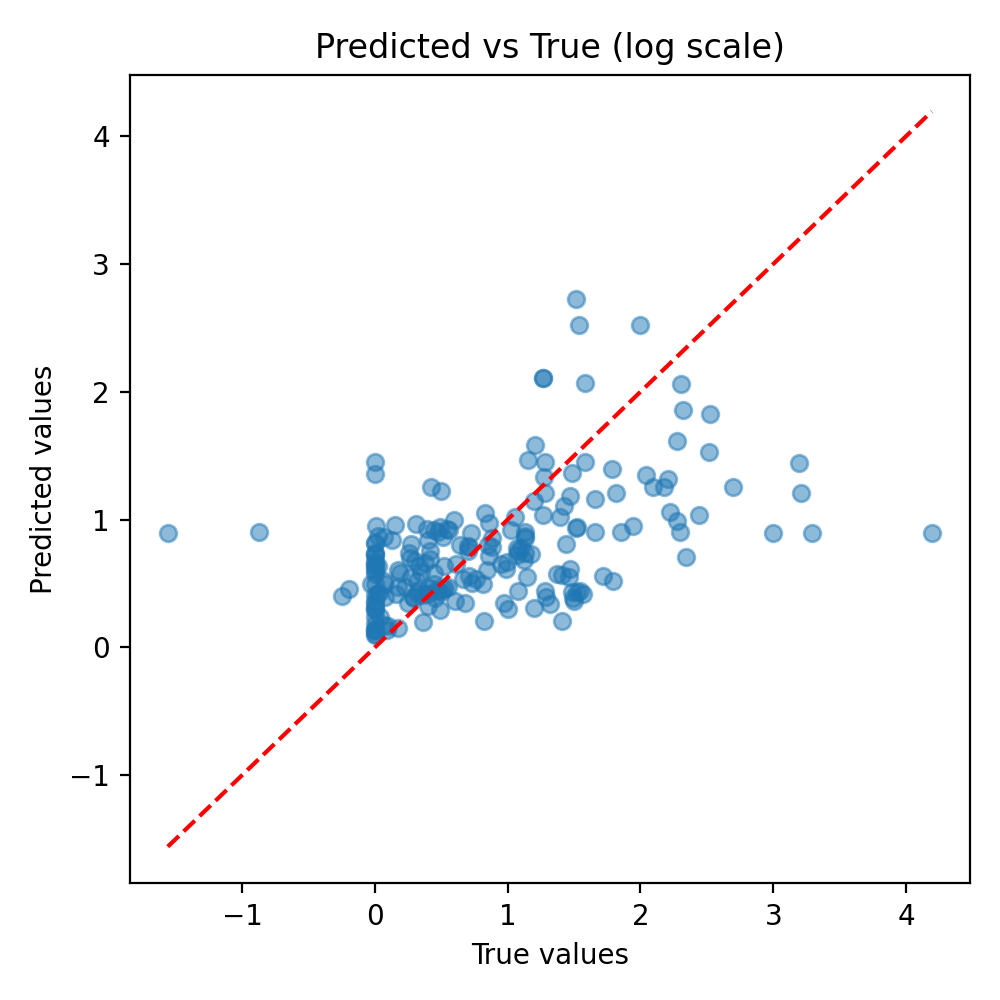

Анализ графиков

1. График Predicted vs True: Наблюдается значительный разброс точек. Модель относительно успешно предсказывает средние значения, но систематически ошибается на хвостах распределения, особенно в зоне высоких значений SI, которые представляют наибольший интерес для поиска лекарственных кандидатов.
2. График Residuals: Распределение ошибок случайно. Однако общий уровень ошибки остается высоким, что связано с высокой дисперсией исходного целевого показателя.

Прямая регрессия не справляется с предсказание SI. Необходимо перейти от задачи регрессии к задаче классификации: например, разделение соединений на классы селективные и неселективные по порогу SI>8. Для практического применения в разработке лекарств важнее надежная идентификация перспективных соединений, чем точный расчет индекса в условиях высокой экспериментальной погрешности. Также несовсем понятно зачем делать регрессию вычисляемого признака, тк с предсказанием основных признаков регрессия справляется хорошо.